# World Data in PySpark

Same version as world data which uses Pandas but in PySpark

In [1]:
from pathlib import Path

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder.appName("world-data-pyspark").master("local[*]").getOrCreate()

DATA_DIR = Path(r"D:\Files\Documents\GitHub\world-data\data")

def show_table(df, rows=20):
    try:
        display(df)
    except NameError:
        df.show(rows, truncate=False)

def clean_column_names(df):
    for column_name in df.columns:
        stripped_name = column_name.strip()
        if stripped_name != column_name:
            df = df.withColumnRenamed(column_name, stripped_name)
    return df

def read_csv(filename):
    df = (
        spark.read.option("header", True)
        .option("inferSchema", True)
        .option("ignoreLeadingWhiteSpace", True)
        .csv(str(DATA_DIR / filename))
    )
    return clean_column_names(df)


## Load CSV Files

In [2]:
# Local path for this repo. In Databricks, upload/copy the data folder to DBFS
# and change DATA_DIR, for example: Path('/dbfs/FileStore/world-data/data')
DATA_DIR = Path("data")

names = read_csv("country_name.csv")
areas = read_csv("country_area.csv")
iso = read_csv("country_name_iso_3166.csv")
pop = read_csv("country_population.csv").withColumnRenamed("year", "population_year")
gdp = read_csv("country_gdp.csv").withColumnRenamed("year", "gdp_year")

counts = spark.createDataFrame(
    [
        ("names", names.count()),
        ("areas", areas.count()),
        ("iso", iso.count()),
        ("pop", pop.count()),
        ("gdp", gdp.count()),
    ],
    ["table", "rows"],
)

show_table(counts)

DataFrame[table: string, rows: bigint]

## Join and Derive Fields

In [3]:
df = (
    iso.join(names, on="alpha_3_code", how="left")
    .join(areas, on="alpha_3_code", how="left")
    .join(pop, on="alpha_3_code", how="left")
    .join(gdp, on="alpha_3_code", how="left")
    .withColumn("total_area", F.col("land") + F.coalesce(F.col("water"), F.lit(0)))
    .withColumn("pop_density", F.when(F.col("land") > 0, F.col("population") / F.col("land")))
)

show_table(df.limit(5))

DataFrame[alpha_3_code: string, english_short_name: string, french_short_name: string, alpha_2_code: string, numeric: int, common_english_name: string, official_country_name: string, land: int, water: int, population: int, population_year: int, gdp_usd: bigint, gdp_year: int, total_area: int, pop_density: double]

## Land Area

In [4]:
largest_land = df.orderBy(F.col("land").desc()).select(
    "english_short_name", "alpha_3_code", "land", "water"
)

show_table(largest_land.limit(10))

DataFrame[english_short_name: string, alpha_3_code: string, land: int, water: int]

In [5]:
smallest_land = (
    df.filter(F.col("land") > 0)
    .orderBy(F.col("land"))
    .select("english_short_name", "alpha_3_code", "land", "water")
)

show_table(smallest_land.limit(10))

DataFrame[english_short_name: string, alpha_3_code: string, land: int, water: int]

In [6]:
top20_land = (
    df.orderBy(F.col("land").desc())
    .limit(20)
    .orderBy(F.col("land"))
    .select("english_short_name", (F.col("land") / 1_000_000).alias("land_million_km2"))
)

show_table(top20_land)

DataFrame[english_short_name: string, land_million_km2: double]

## Population

In [7]:
most_populous = df.orderBy(F.col("population").desc()).select(
    "english_short_name", "alpha_3_code", "population", "population_year"
)

show_table(most_populous.limit(10))

DataFrame[english_short_name: string, alpha_3_code: string, population: int, population_year: int]

In [8]:
least_populous = (
    df.filter(F.col("population") > 0)
    .orderBy(F.col("population"))
    .select("english_short_name", "alpha_3_code", "population", "population_year")
)

show_table(least_populous.limit(10))

DataFrame[english_short_name: string, alpha_3_code: string, population: int, population_year: int]

In [9]:
top20_population = (
    df.orderBy(F.col("population").desc())
    .limit(20)
    .orderBy(F.col("population"))
    .select("english_short_name", (F.col("population") / 1_000_000).alias("population_millions"))
)

show_table(top20_population)

DataFrame[english_short_name: string, population_millions: double]

## Population Density

In [10]:
densest = (
    df.filter(F.col("land") > 0)
    .orderBy(F.col("pop_density").desc())
    .select("english_short_name", "alpha_3_code", "population", "land", F.round("pop_density", 1).alias("pop_density"))
)

show_table(densest.limit(10))

DataFrame[english_short_name: string, alpha_3_code: string, population: int, land: int, pop_density: double]

In [11]:
top20_density = (
    df.filter(F.col("land") > 0)
    .orderBy(F.col("pop_density").desc())
    .limit(20)
    .orderBy(F.col("pop_density"))
    .select("english_short_name", "pop_density")
)

show_table(top20_density)

DataFrame[english_short_name: string, pop_density: double]

## GDP

In [12]:
largest_economies = df.orderBy(F.col("gdp_usd").desc()).select(
    "english_short_name", "alpha_3_code", "gdp_usd", "gdp_year"
)

show_table(largest_economies.limit(10))

DataFrame[english_short_name: string, alpha_3_code: string, gdp_usd: bigint, gdp_year: int]

In [13]:
top20_gdp = (
    df.orderBy(F.col("gdp_usd").desc())
    .limit(20)
    .orderBy(F.col("gdp_usd"))
    .select("english_short_name", (F.col("gdp_usd") / 1_000_000_000_000).alias("gdp_trillion_usd"))
)

show_table(top20_gdp)

DataFrame[english_short_name: string, gdp_trillion_usd: double]

## Optional Matplotlib Charts

Databricks can chart the `display(...)` results directly. Use these cells if you want the notebook to reproduce the matplotlib charts from the original notebook.

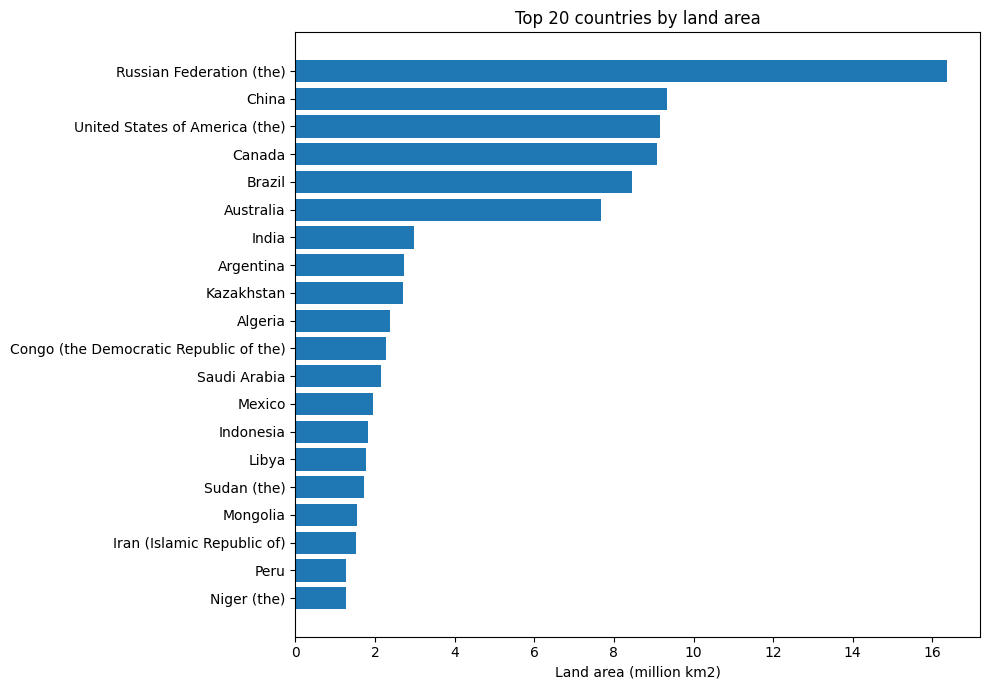

In [14]:
import matplotlib.pyplot as plt

pdf = top20_land.toPandas()
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(pdf["english_short_name"], pdf["land_million_km2"])
ax.set_xlabel("Land area (million km2)")
ax.set_title("Top 20 countries by land area")
plt.tight_layout()
plt.show()

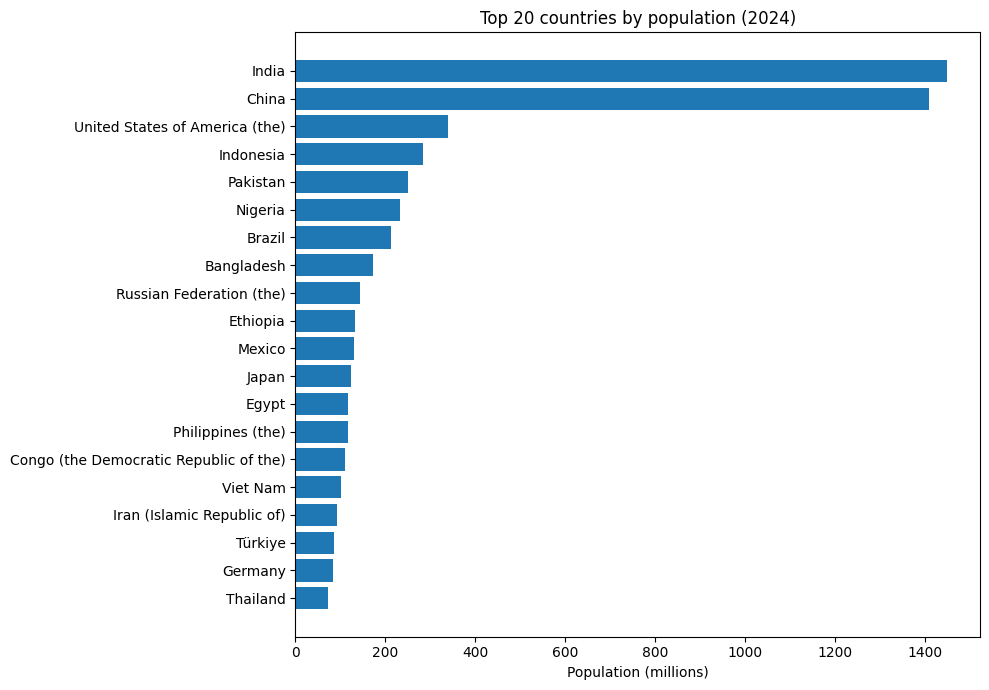

In [15]:
pdf = top20_population.toPandas()
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(pdf["english_short_name"], pdf["population_millions"])
ax.set_xlabel("Population (millions)")
ax.set_title("Top 20 countries by population (2024)")
plt.tight_layout()
plt.show()

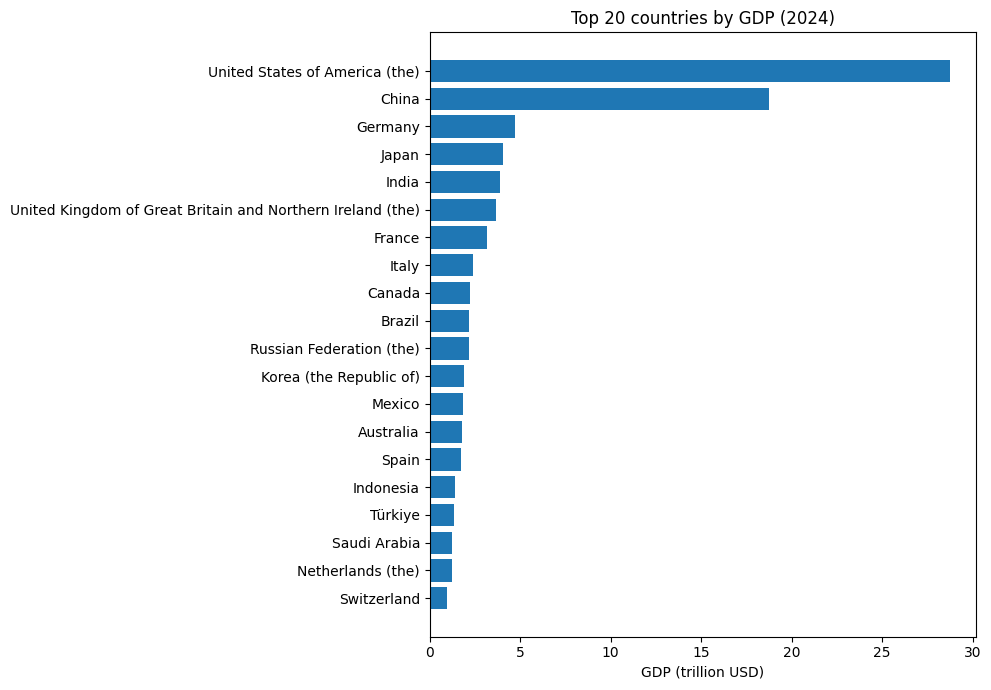

In [16]:
pdf = top20_gdp.toPandas()
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(pdf["english_short_name"], pdf["gdp_trillion_usd"])
ax.set_xlabel("GDP (trillion USD)")
ax.set_title("Top 20 countries by GDP (2024)")
plt.tight_layout()
plt.show()